In [26]:
import pandas as pd
from cdc_ml.config import POLLS_PROCESSED, CUSTOMER_CLASS_PROCESSED
from cdc_ml.config import POLLS_PROCESSED,CUSTOMER_CLASS_PROCESSED
from cdc_ml.features.build_features import assign_class_type
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [27]:
df = pd.read_parquet(POLLS_PROCESSED)
df_class = pd.read_parquet(CUSTOMER_CLASS_PROCESSED)
df = assign_class_type(df,df_class)

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32492 entries, 0 to 32491
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype                         
---  ------             --------------  -----                         
 0   id                 32492 non-null  int64                         
 1   cycle_id           32492 non-null  int64                         
 2   username           32492 non-null  str                           
 3   cycle_start        32492 non-null  datetime64[us, Asia/Singapore]
 4   cycle_end          32492 non-null  datetime64[us, Asia/Singapore]
 5   polling_at         32492 non-null  datetime64[us, Asia/Singapore]
 6   has_booking        32492 non-null  bool                          
 7   cycle_start_month  32492 non-null  int32                         
 8   cycle_start_day    32492 non-null  int32                         
 9   cycle_start_dow    32492 non-null  int32                         
 10  cycle_start_hour   32492 non-null  int32     

In [29]:
df.tail()

,id,cycle_id,username,cycle_start,cycle_end,polling_at,has_booking,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,polling_month,polling_day,polling_dow,polling_hour,hours_into_cycle,class_type,is_one_team
32487,32487,121,addity,2025-10-16 00:00:00+08:00,2025-10-17 20:00:00+08:00,2025-10-17 16:00:00+08:00,False,10,16,3,0,10,17,4,16,40.0,1,1
32488,32488,121,addity,2025-10-16 00:00:00+08:00,2025-10-17 20:00:00+08:00,2025-10-17 17:00:00+08:00,False,10,16,3,0,10,17,4,17,41.0,1,1
32489,32489,121,addity,2025-10-16 00:00:00+08:00,2025-10-17 20:00:00+08:00,2025-10-17 18:00:00+08:00,True,10,16,3,0,10,17,4,18,42.0,1,1
32490,32490,121,addity,2025-10-16 00:00:00+08:00,2025-10-17 20:00:00+08:00,2025-10-17 19:00:00+08:00,False,10,16,3,0,10,17,4,19,43.0,1,1
32491,32491,121,addity,2025-10-16 00:00:00+08:00,2025-10-17 20:00:00+08:00,2025-10-17 20:00:00+08:00,False,10,16,3,0,10,17,4,20,44.0,1,1


In [30]:
#df = df.loc[~(df["username"]=="anmol")]

In [31]:
counts = df["has_booking"].value_counts()
shares = df["has_booking"].value_counts(normalize=True)

tp = pd.concat([counts, shares], axis=1)
tp.columns = ["count", "share"]

In [32]:
tp

,count,share
has_booking,,
False,32096,0.987812
True,396,0.012188


In [33]:
def eda_label_rate(x):
    label_rate = (
        df.groupby(x)["has_booking"]
        .agg(share="mean", count="count")
        .reset_index()
    )
    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    # Top: label rate with 95% CI
    sns.barplot(data=df, x=x, y="has_booking", ax=axes[0], errorbar=("ci", 95))
    axes[0].set_ylabel("P(has_booking)")

    # Bottom: exposure per category
    sns.barplot(data=label_rate, x=x, y="count", ax=axes[1], color="steelblue")
    axes[1].set_ylabel("n observations")

    plt.tight_layout()


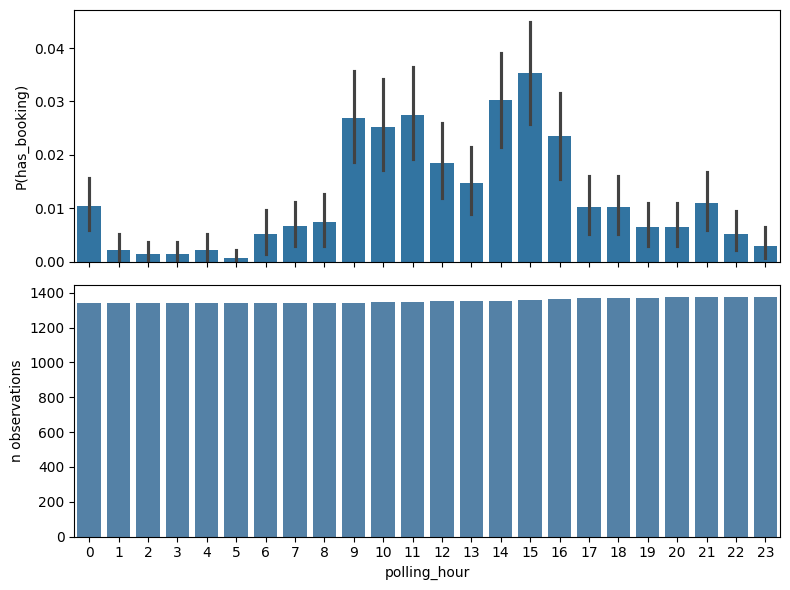

In [34]:
eda_label_rate("polling_hour")

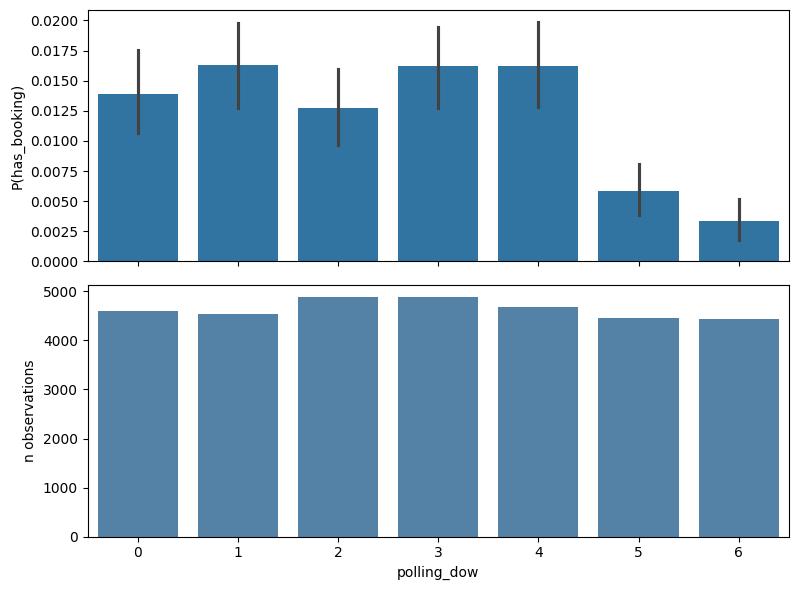

In [35]:
eda_label_rate("polling_dow")

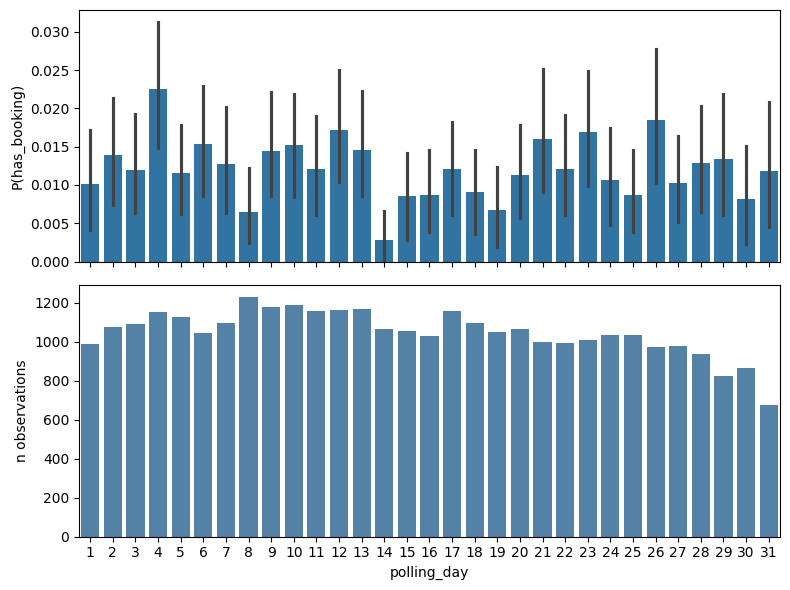

In [36]:
eda_label_rate("polling_day")

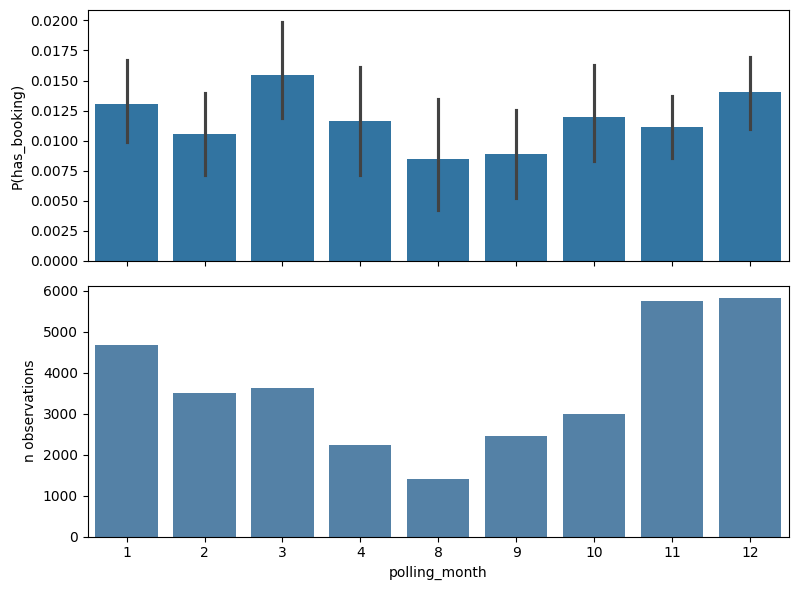

In [37]:
label_rate_by_polling_month = eda_label_rate("polling_month")

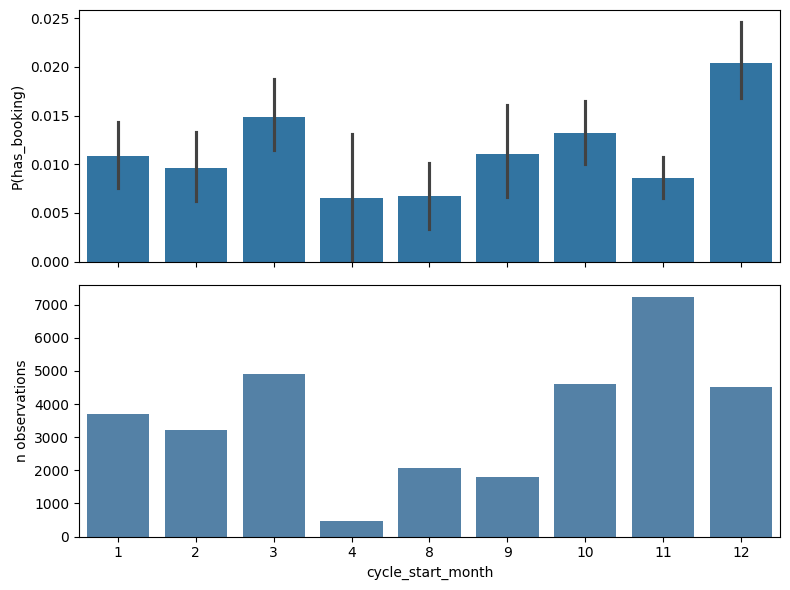

In [38]:
eda_label_rate("cycle_start_month")

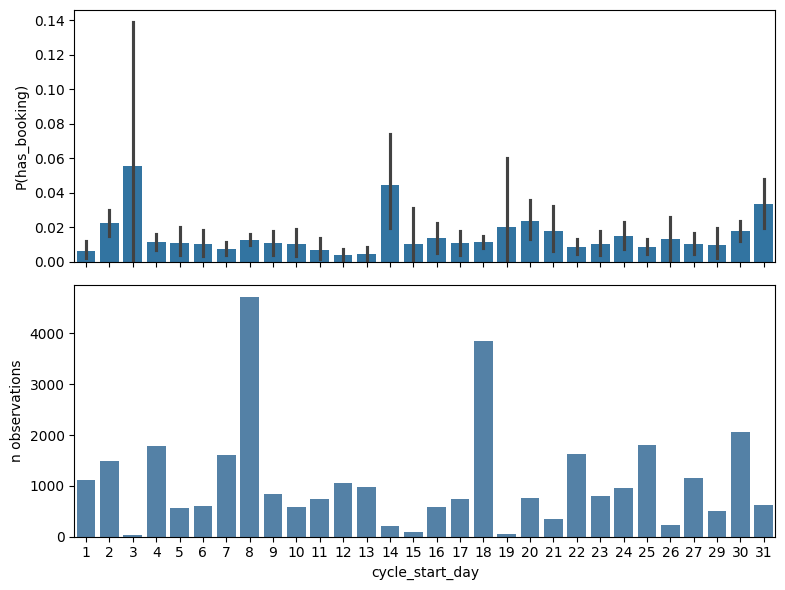

In [39]:
eda_label_rate("cycle_start_day")

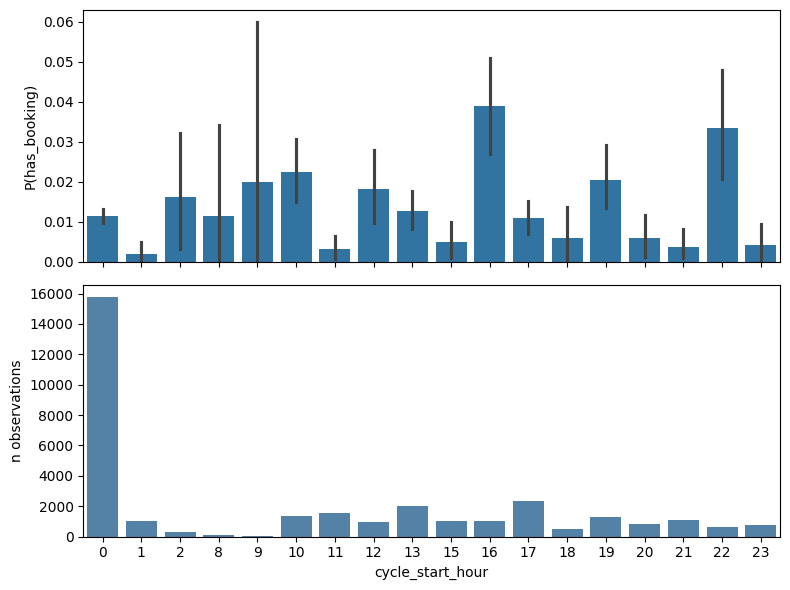

In [40]:
eda_label_rate("cycle_start_hour")

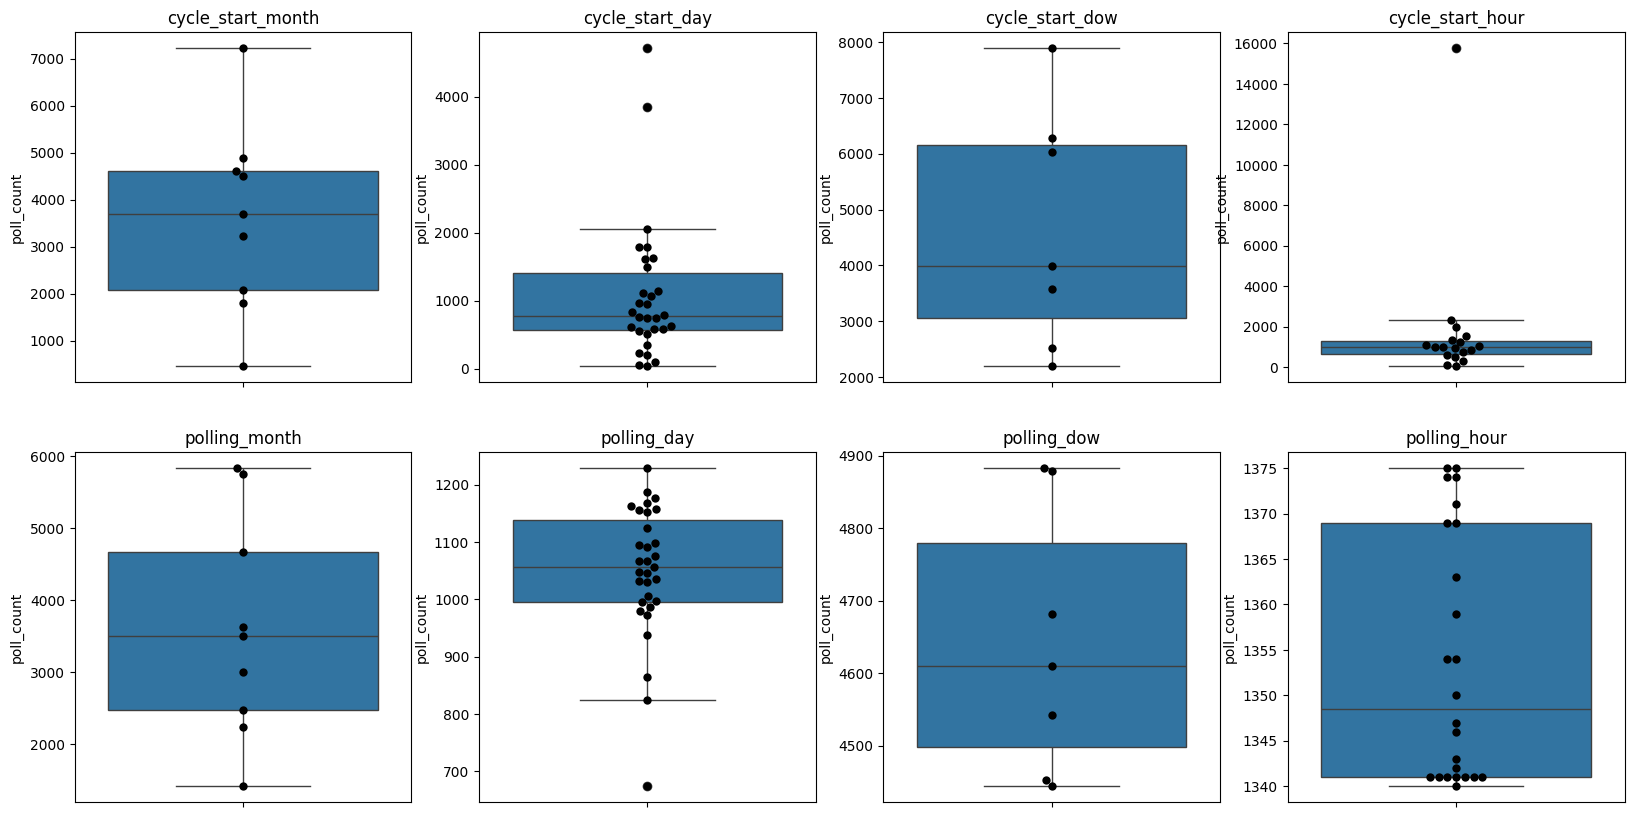

In [41]:
fig,axes = plt.subplots(2,4,figsize=(20,10))

plot_lists = [["cycle_start_month","cycle_start_day","cycle_start_dow","cycle_start_hour",],
              ["polling_month","polling_day","polling_dow","polling_hour"]
              ]

for i in range(2):
    for j in range(4):
        current = plot_lists[i][j]
        count = df.groupby(current)["username"].count().reset_index(name="poll_count")
        sns.boxplot(y=count["poll_count"],ax=axes[i][j])
        sns.swarmplot(y=count["poll_count"], color="black", size=6,ax=axes[i][j])
        axes[i][j].set_title(current)  

In [42]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(df, x, y):
    ct = pd.crosstab(df[x], df[y])
    chi2, p, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    k = min(ct.shape) - 1                       # df_min — drives the thresholds
    v = np.sqrt(chi2 / (n * k))

    small, medium, large = (c / np.sqrt(k) for c in (0.10, 0.30, 0.50))
    if   v >= large:  label = "large"
    elif v >= medium: label = "medium"
    elif v >= small:  label = "small"
    else:             label = "negligible / no association"

    print(f"χ²={chi2:.1f}  p={p:.2e}  V={v:.3f}  (df={k})  → {label}")
    return v, p


In [43]:
cramers_v(df,"cycle_start_month","polling_month")

χ²=147999.9  p=0.00e+00  V=0.755  (df=8)  → large


(np.float64(0.7545663641083301), np.float64(0.0))

In [44]:
cramers_v(df,"cycle_start_day","polling_day")

χ²=30414.3  p=0.00e+00  V=0.180  (df=29)  → large


(np.float64(0.17966023788761307), np.float64(0.0))

In [45]:
cramers_v(df,"cycle_start_hour","polling_hour")

χ²=21.0  p=1.00e+00  V=0.006  (df=17)  → negligible / no association


(np.float64(0.006172619848423973), np.float64(1.0))

In [46]:

cramers_v(df,"polling_month","polling_day")

χ²=6391.3  p=0.00e+00  V=0.157  (df=8)  → medium


(np.float64(0.15680510962772454), np.float64(0.0))

In [47]:
cramers_v(df,"polling_day","polling_dow")

χ²=13527.8  p=0.00e+00  V=0.263  (df=6)  → large


(np.float64(0.2634206701090311), np.float64(0.0))

In [48]:
cramers_v(df,"polling_dow","polling_hour")

χ²=2.2  p=1.00e+00  V=0.003  (df=6)  → negligible / no association


(np.float64(0.0033436064144391716), np.float64(1.0))

In [49]:
cramers_v(df,"polling_dow","has_booking")

χ²=64.0  p=6.88e-12  V=0.044  (df=1)  → negligible / no association


(np.float64(0.04438382902520483), np.float64(6.880025239948605e-12))

In [50]:

cramers_v(df,"polling_hour","has_booking")

χ²=283.5  p=9.53e-47  V=0.093  (df=1)  → negligible / no association


(np.float64(0.09341552758594342), np.float64(9.53468794482356e-47))

In [51]:
df["username"].value_counts(normalize=True).sort_values(ascending=False)

username
kim        0.117444
jy         0.072695
flower     0.069709
anmol      0.062846
ryan       0.060538
anaya      0.053182
mya        0.050474
matt       0.048412
ali        0.047704
srpr       0.046165
faith      0.035055
tomato     0.033024
brendon    0.032131
joy        0.025822
jun        0.025637
apple      0.024129
poopie     0.023329
gohguan    0.021698
natar      0.016989
fir        0.016004
bw         0.014804
addity     0.014465
np         0.013080
bryan      0.010833
lucinda    0.009048
d          0.008125
aswath     0.006802
nur        0.006648
phuc       0.006432
carol      0.005909
sara       0.005447
pakning    0.004647
bhara      0.004432
isyaf      0.002216
ajithak    0.001539
max        0.001477
ranjith    0.001108
Name: proportion, dtype: float64

In [52]:
df.groupby(["username"])["has_booking"].sum().sort_values(ascending=False)

username
anmol      84
jy         37
poopie     31
joy        24
jun        23
mya        23
kim        22
flower     15
tomato     14
srpr       14
faith      13
apple       9
ryan        8
brendon     8
anaya       7
ali         6
bryan       6
np          5
addity      5
nur         4
aswath      4
carol       4
matt        4
lucinda     3
pakning     3
phuc        3
bhara       3
sara        2
fir         2
gohguan     2
natar       2
ajithak     1
bw          1
isyaf       1
d           1
max         1
ranjith     1
Name: has_booking, dtype: int64

   username  has_booking
32     ryan         1967
33    anmol         2042
34   flower         2265
35       jy         2362
36      kim         3816


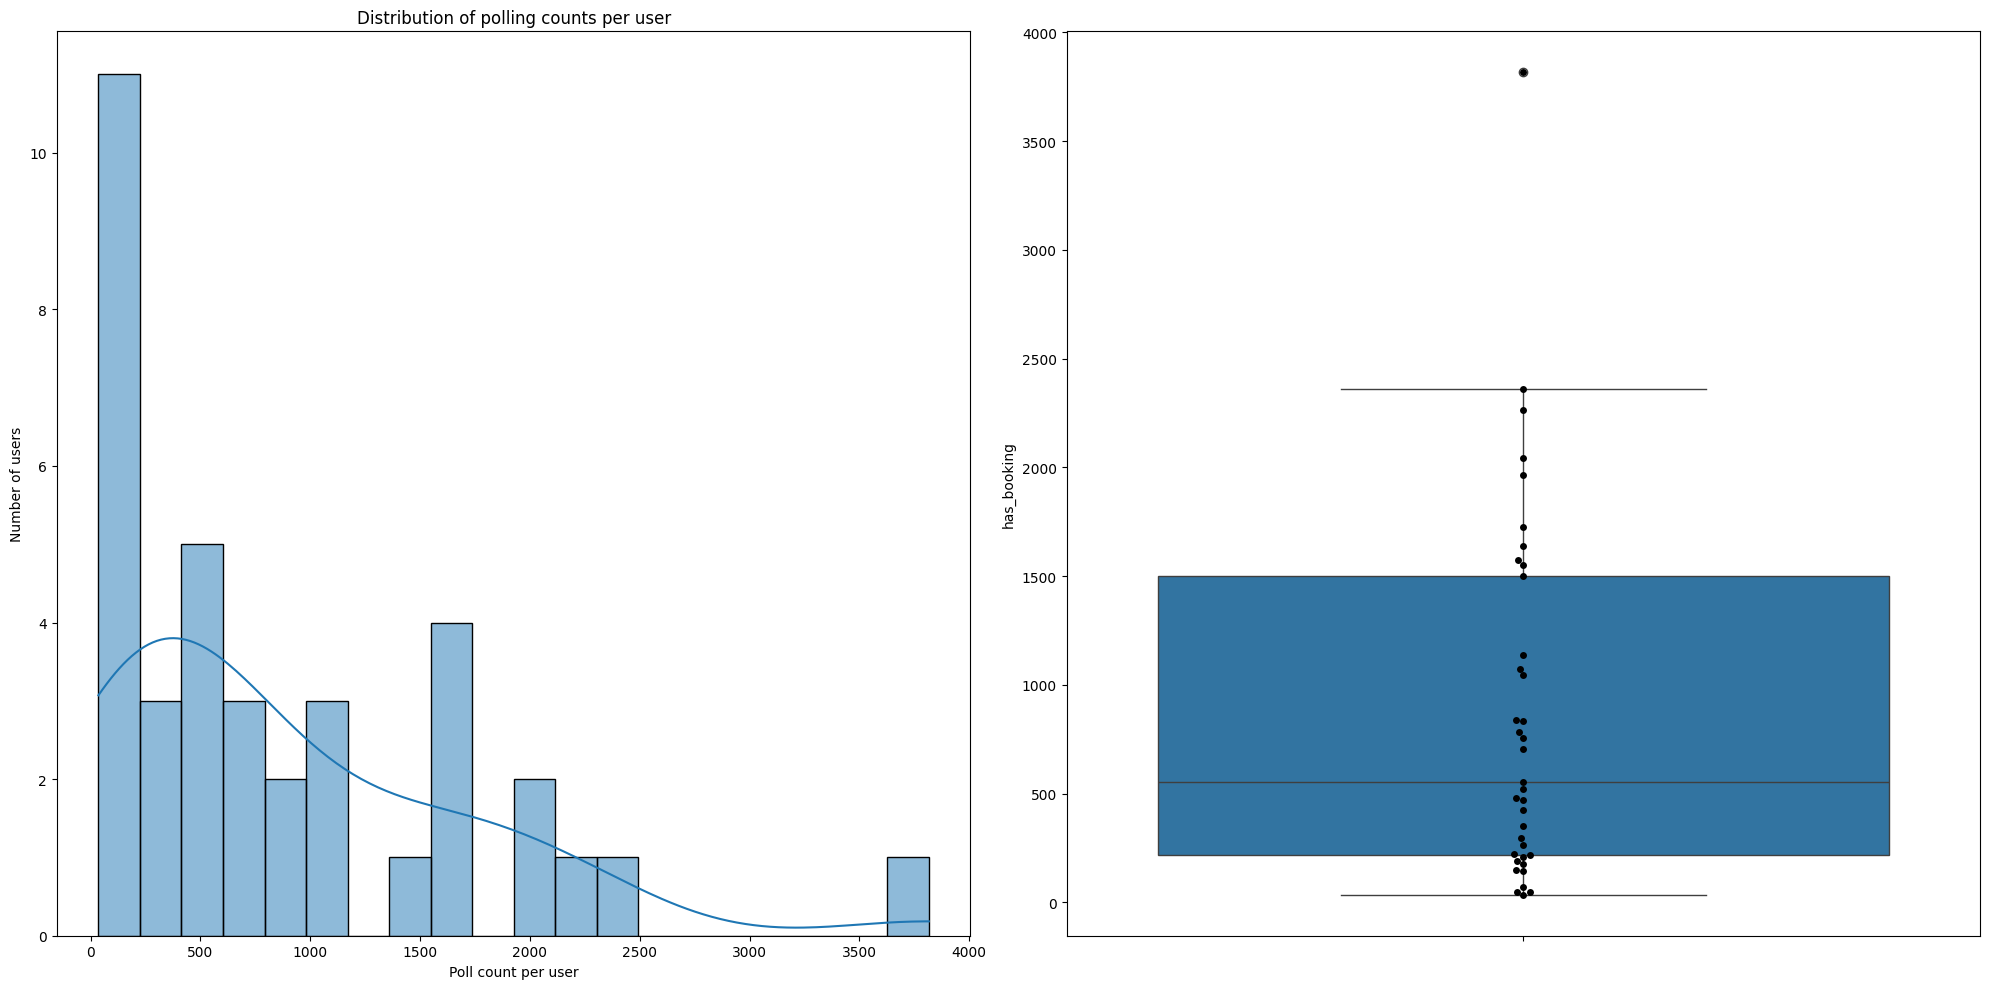

In [53]:
user_distribution = df.groupby("username")["has_booking"].count().sort_values().reset_index()
print(user_distribution.tail())

fig, axes = plt.subplots(1,2,figsize=(20, 10))
sns.histplot(
    data=user_distribution,
    x="has_booking",
    bins=20,
    kde=True,      
    ax=axes[0]
)
axes[0].set_xlabel("Poll count per user")
axes[0].set_ylabel("Number of users")
axes[0].set_title("Distribution of polling counts per user")

sns.boxplot(data=user_distribution,y="has_booking",ax=axes[1])
sns.swarmplot(data=user_distribution,y="has_booking",color="black",ax=axes[1])
plt.tight_layout()
plt.show()

In [54]:
count = df.groupby(["username"])["has_booking"].count().reset_index()
q_25,q_50,q_75 = count["has_booking"].quantile([0.25,0.5,0.75])

iqr = q_75 - q_25
print(q_25,q_50,q_75,iqr)

216.0 552.0 1500.0 1284.0


<Axes: xlabel='poll_count', ylabel='booking_rate'>

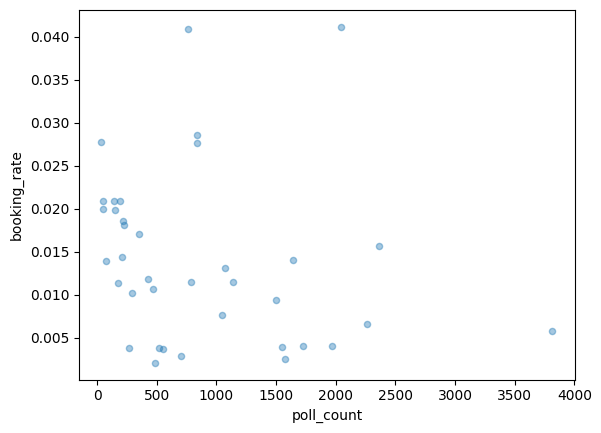

In [55]:
stats = df.groupby("username")["has_booking"].agg(["count", "mean"]).reset_index()
stats.columns = ["username", "poll_count", "booking_rate"]

# Does booking rate correlate with how long they've been observed?
stats.plot.scatter(x="poll_count", y="booking_rate", alpha=0.4)

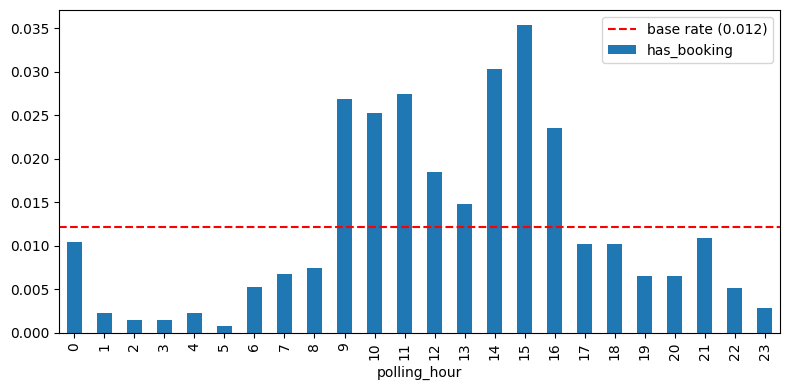

In [56]:
def success_share(x):
    rate = df.groupby(x)["has_booking"].mean()
    base = df["has_booking"].mean()
    
    fig, ax = plt.subplots(figsize=(8, 4))
    rate.plot(kind="bar", ax=ax)
    ax.axhline(base, color="red", linestyle="--", label=f"base rate ({base:.3f})")
    ax.legend()
    plt.tight_layout()
    plt.show()

success_share("polling_hour")


   username  count     share
0       kim   3816  0.117444
1        jy   2362  0.072695
2    flower   2265  0.069709
3     anmol   2042  0.062846
4      ryan   1967  0.060538
5     anaya   1728  0.053182
6       mya   1640  0.050474
7      matt   1573  0.048412
8       ali   1550  0.047704
9      srpr   1500  0.046165
10    faith   1139  0.035055
11   tomato   1073  0.033024
12  brendon   1044  0.032131
13      joy    839  0.025822
14      jun    833  0.025637
15    apple    784  0.024129
16   poopie    758  0.023329
17  gohguan    705  0.021698
18    natar    552  0.016989
19      fir    520  0.016004
20       bw    481  0.014804
21   addity    470  0.014465
22       np    425  0.013080
23    bryan    352  0.010833
24  lucinda    294  0.009048
25        d    264  0.008125
26   aswath    221  0.006802
27      nur    216  0.006648
28     phuc    209  0.006432
29    carol    192  0.005909
30     sara    177  0.005447
31  pakning    151  0.004647
32    bhara    144  0.004432
33    isyaf   

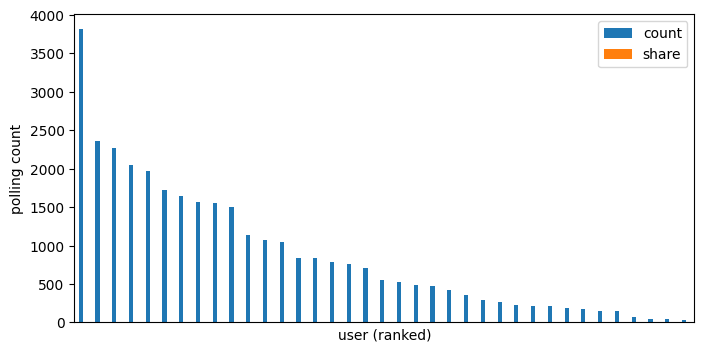

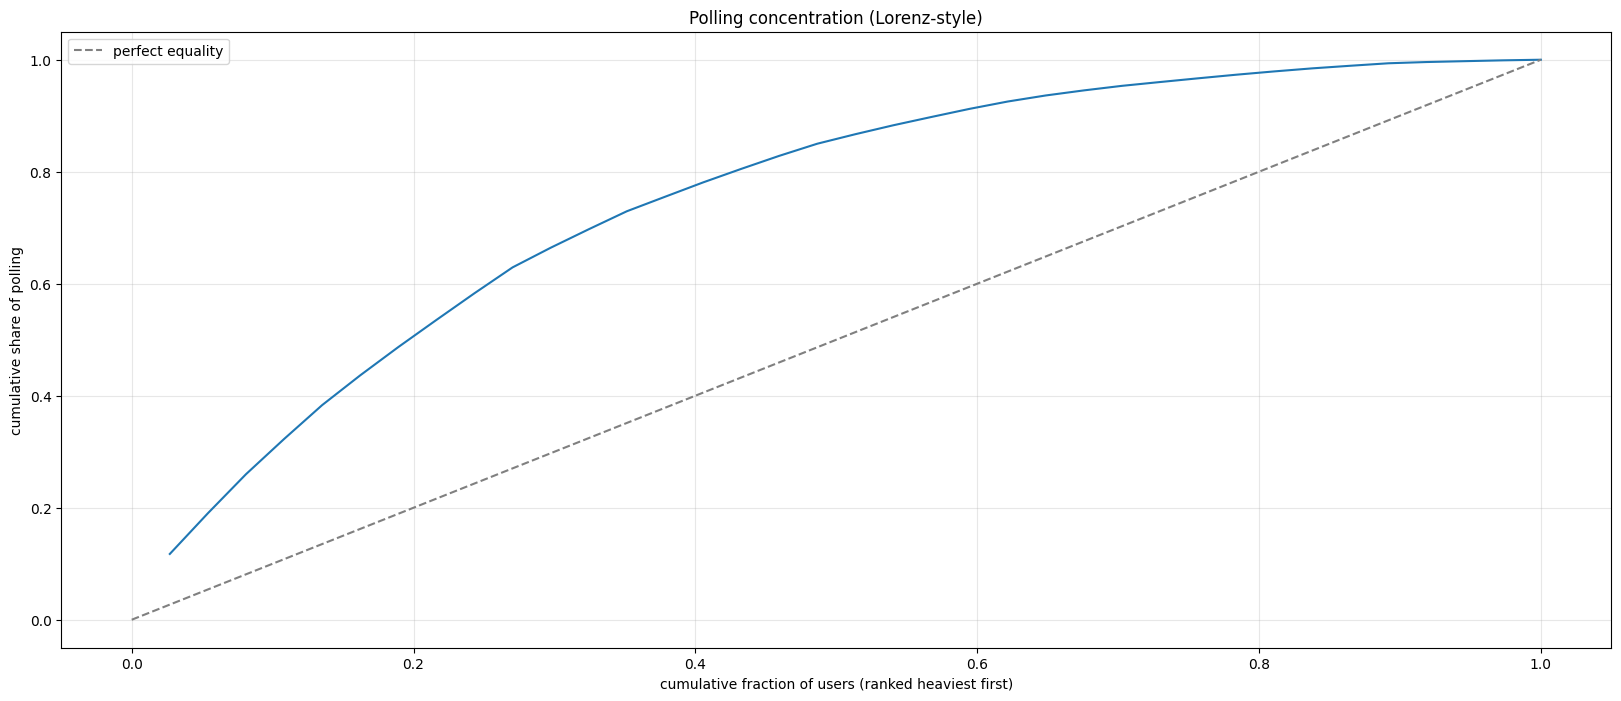

In [57]:
counts = df['username'].value_counts().reset_index().assign(share=lambda x:x["count"]/len(df))
print(counts)

fig, ax = plt.subplots(figsize=(8, 4))
counts.plot(kind='bar', ax=ax)
ax.set_ylabel('polling count')
ax.set_xlabel('user (ranked)')
ax.set_xticks([])  # hide labels if there are many users


counts_sorted = (
    counts.sort_values('share', ascending=False)
          .reset_index(drop=True)
)
counts_sorted['cum_share'] = counts_sorted['share'].cumsum()
counts_sorted['cum_user_frac'] = (counts_sorted.index + 1) / len(counts_sorted)

fig, ax = plt.subplots(figsize=(20, 8))
ax.plot(counts_sorted['cum_user_frac'], counts_sorted['cum_share'])
ax.plot([0, 1], [0, 1], '--', color='gray', label='perfect equality')
ax.set_xlabel('cumulative fraction of users (ranked heaviest first)')
ax.set_ylabel('cumulative share of polling')
ax.set_title('Polling concentration (Lorenz-style)')
ax.grid(True, alpha=0.3)
ax.legend()

for k in [0.05, 0.10, 0.20, 0.50]:
    n = max(1, int(k * len(counts_sorted)))
    print(f'top {k:.0%} of users ({n}) → {counts_sorted["share"].head(n).sum():.1%} of polls')

In [58]:
import numpy as np

def gini(x):
    x = np.sort(np.asarray(x))
    n = len(x)
    return (2 * np.sum((np.arange(1, n + 1)) * x) - (n + 1) * x.sum()) / (n * x.sum())

print(f'Gini: {gini(counts["share"].values):.3f}')

Gini: 0.498


top 5% of users (1) → 11.7% of polls
top 10% of users (3) → 26.0% of polls
top 20% of users (7) → 48.7% of polls
top 50% of users (18) → 85.0% of polls


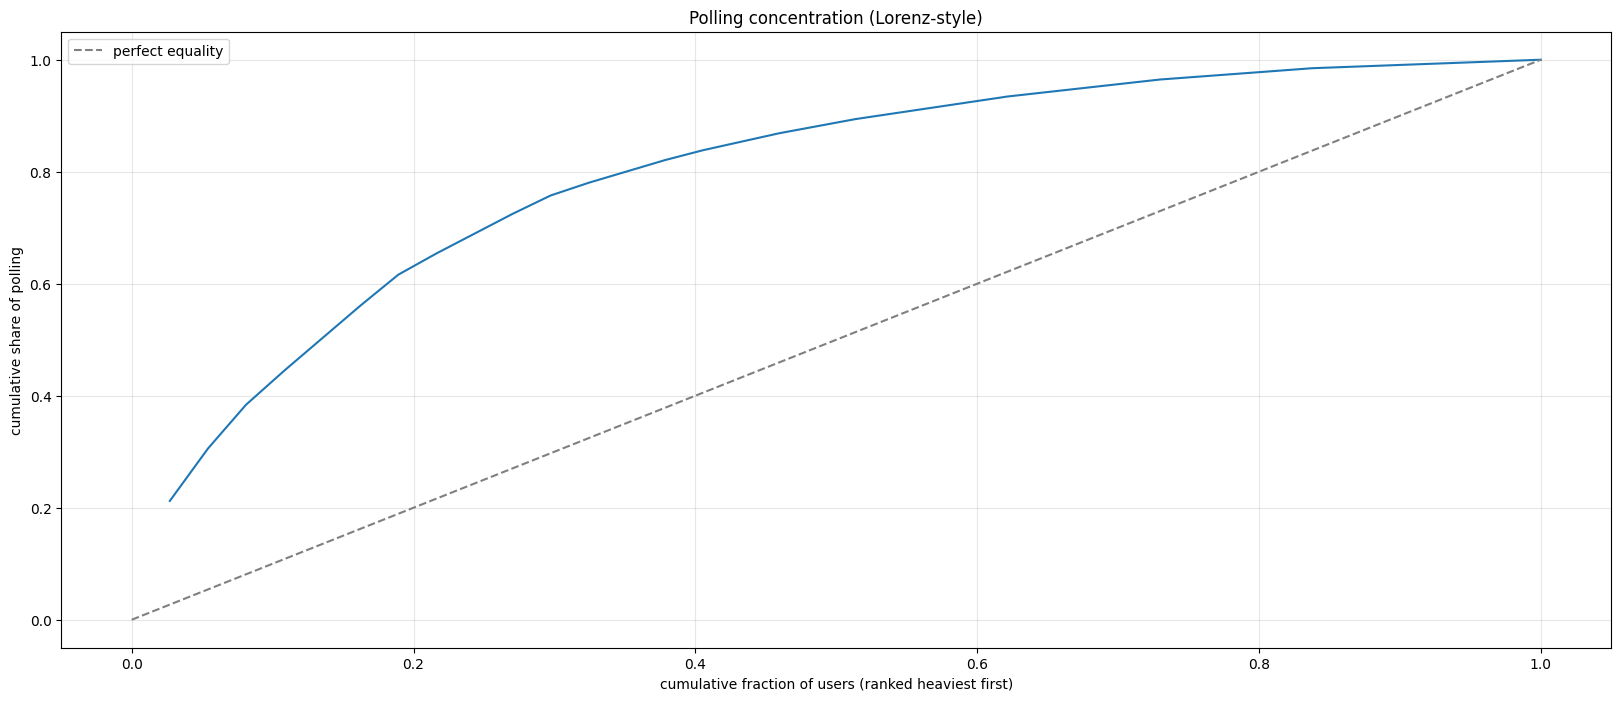

In [59]:
total_sum = df["has_booking"].sum()
whales_sum = df.groupby(["username"])["has_booking"].sum().sort_values(ascending=False).reset_index(name="sum")
whales_sum["share"] = whales_sum["sum"]/total_sum


whales_sum["cum_share"] = whales_sum["share"].cumsum()
whales_sum["cum_frac"] = ((whales_sum.index +1) / len(whales_sum))


fig, ax = plt.subplots(figsize=(20, 8))
ax.plot(whales_sum['cum_frac'], whales_sum['cum_share'])
ax.plot([0, 1], [0, 1], '--', color='gray', label='perfect equality')
ax.set_xlabel('cumulative fraction of users (ranked heaviest first)')
ax.set_ylabel('cumulative share of polling')
ax.set_title('Polling concentration (Lorenz-style)')
ax.grid(True, alpha=0.3)
ax.legend()

for k in [0.05, 0.10, 0.20, 0.50]:
    n = max(1, int(k * len(counts_sorted)))
    print(f'top {k:.0%} of users ({n}) → {counts_sorted["share"].head(n).sum():.1%} of polls')


In [60]:
whales_count = counts_sorted.iloc[:int(0.10*len(whales_sum))]
print(whales_count)

  username  count     share  cum_share  cum_user_frac
0      kim   3816  0.117444   0.117444       0.027027
1       jy   2362  0.072695   0.190139       0.054054
2   flower   2265  0.069709   0.259849       0.081081


In [61]:
whales_positive_share = whales_sum.iloc[:int(0.10*len(whales_sum))]
print(whales_positive_share)

  username  sum     share  cum_share  cum_frac
0    anmol   84  0.212121   0.212121  0.027027
1       jy   37  0.093434   0.305556  0.054054
2   poopie   31  0.078283   0.383838  0.081081


JS divergence (positive-location): 0.258   # 0 = identical pattern, 1 = disjoint


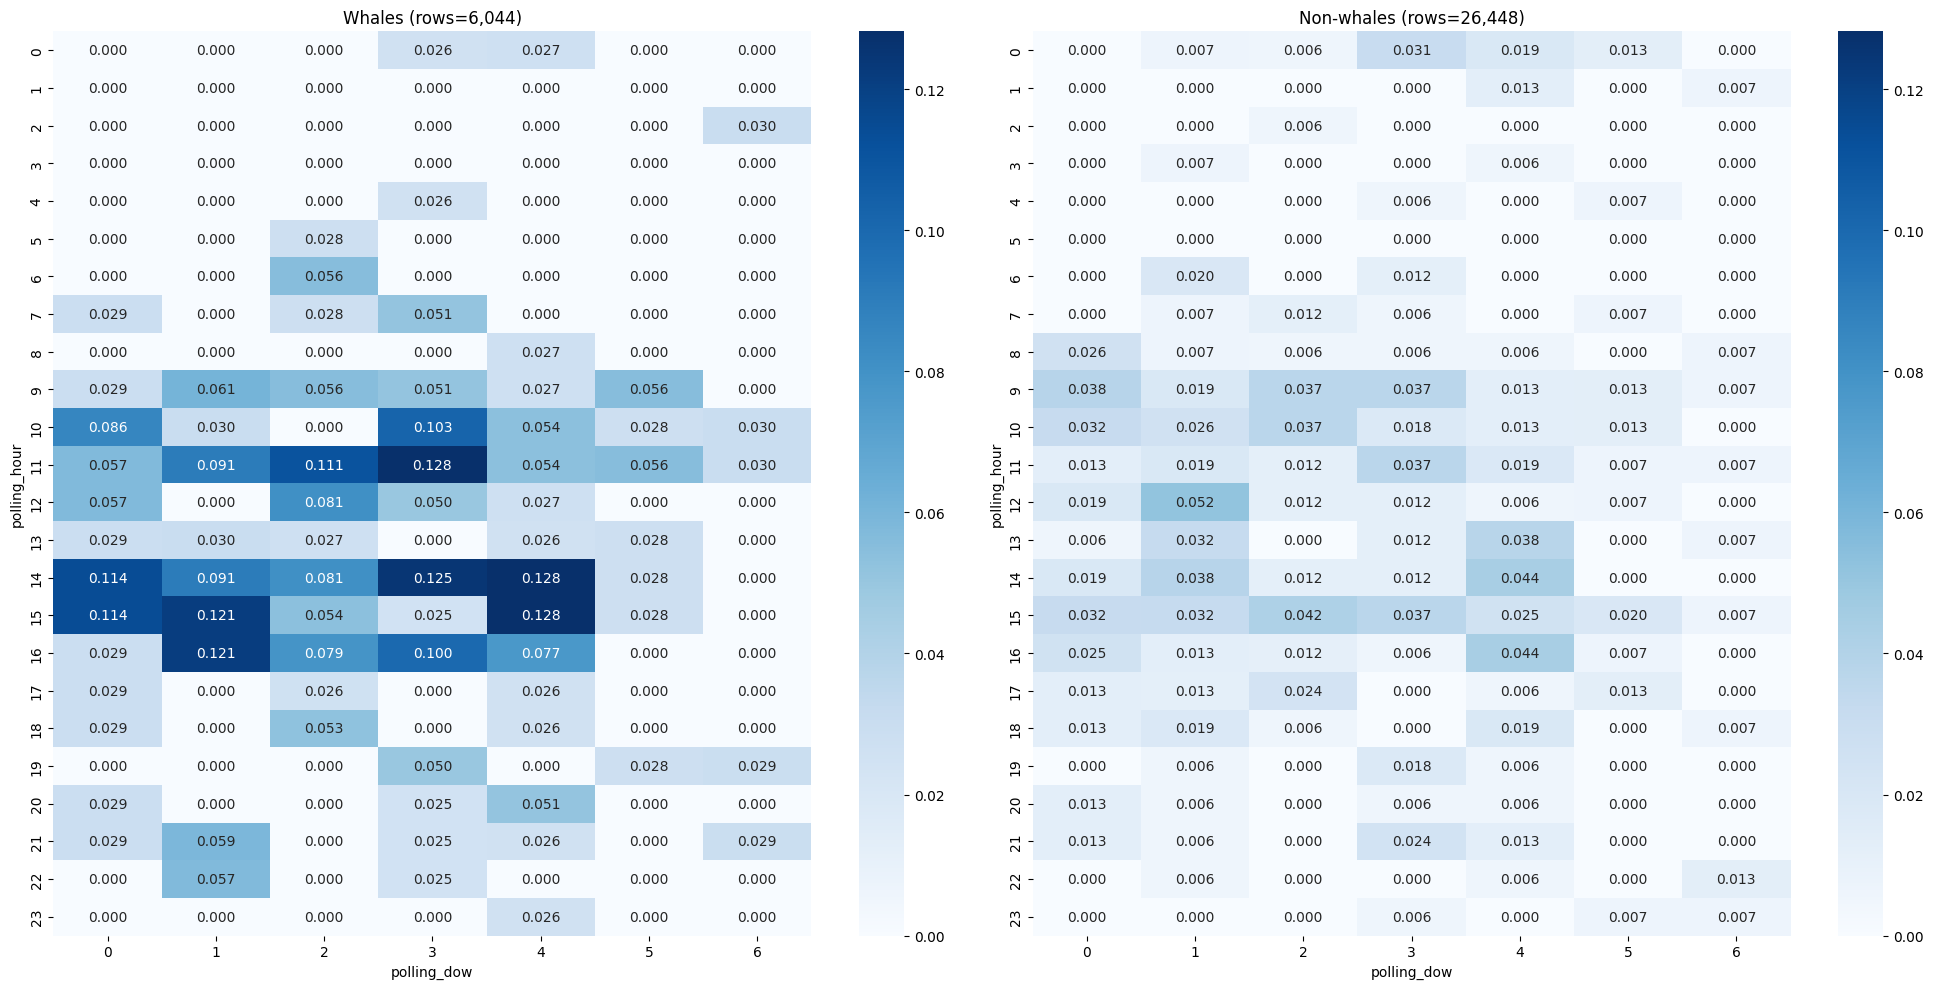

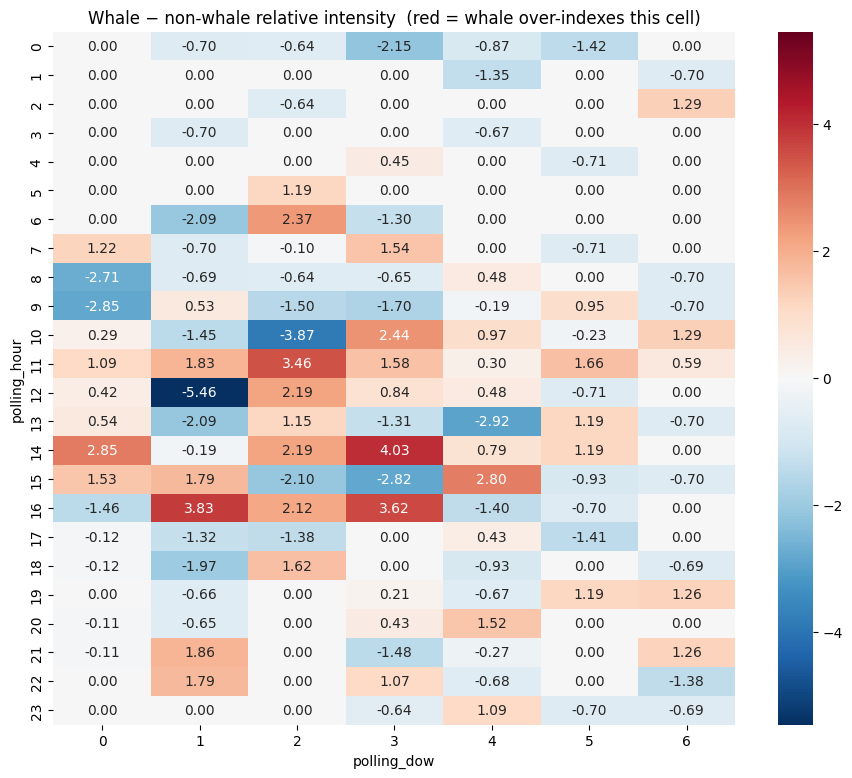

In [62]:
import numpy as np

whales = ["anmol", "jy", "mya"]
is_whale = df["username"].isin(whales)

# Full grid so BOTH heatmaps share identical axes (missing cells -> NaN, not dropped/misaligned)
dows  = sorted(df["polling_dow"].unique())
hours = sorted(df["polling_hour"].unique())

def grid(sub):
    g = sub.groupby(["polling_dow", "polling_hour"])["has_booking"]
    rate    = g.mean().unstack("polling_dow").reindex(index=hours, columns=dows)
    support = g.size().unstack("polling_dow").reindex(index=hours, columns=dows)
    return rate, support

w_rate,  w_support  = grid(df[is_whale])
nw_rate, nw_support = grid(df[~is_whale])

# Mask cells with too few polls to trust the rate (whale side is only 3 users)
MIN_POLLS = 30
w_rate_m  = w_rate.mask(w_support  < MIN_POLLS)
nw_rate_m = nw_rate.mask(nw_support < MIN_POLLS)

# --- FIX 1: shared color scale, so the side-by-side is honest about LEVEL ---
vmax = float(np.nanmax([np.nanmax(w_rate_m.values), np.nanmax(nw_rate_m.values)]))
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
sns.heatmap(w_rate_m,  annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=vmax, ax=axes[0])
sns.heatmap(nw_rate_m, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=vmax, ax=axes[1])
axes[0].set_title(f"Whales (rows={int(is_whale.sum()):,})")
axes[1].set_title(f"Non-whales (rows={int((~is_whale).sum()):,})")
plt.tight_layout()

# --- FIX 2: shape-only difference map, to separate "books more" from "books at different times" ---
w_shape  = w_rate_m  / np.nanmean(w_rate_m.values)     # relative intensity, own mean = 1.0
nw_shape = nw_rate_m / np.nanmean(nw_rate_m.values)
diff = w_shape - nw_shape
fig2, ax2 = plt.subplots(figsize=(11, 9))
lim = float(np.nanmax(np.abs(diff.values)))
sns.heatmap(diff, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-lim, vmax=lim, ax=ax2)
ax2.set_title("Whale − non-whale relative intensity  (red = whale over-indexes this cell)")

# --- FIX 3: one number instead of an eyeball — JS divergence of WHERE positives land ---
def booking_dist(sub):  # distribution of positives across cells, counts-based (no support mask needed)
    c = (sub.groupby(["polling_dow","polling_hour"])["has_booking"].sum()
            .unstack("polling_dow").reindex(index=hours, columns=dows).fillna(0).values.ravel())
    return c / c.sum()

p, q = booking_dist(df[is_whale]), booking_dist(df[~is_whale])
m = 0.5 * (p + q)
kl = lambda a, b: np.sum(a[a > 0] * np.log2(a[a > 0] / b[a > 0]))
js = 0.5 * kl(p, m) + 0.5 * kl(q, m)
print(f"JS divergence (positive-location): {js:.3f}   # 0 = identical pattern, 1 = disjoint")

<Axes: xlabel='hours_into_cycle', ylabel='Count'>

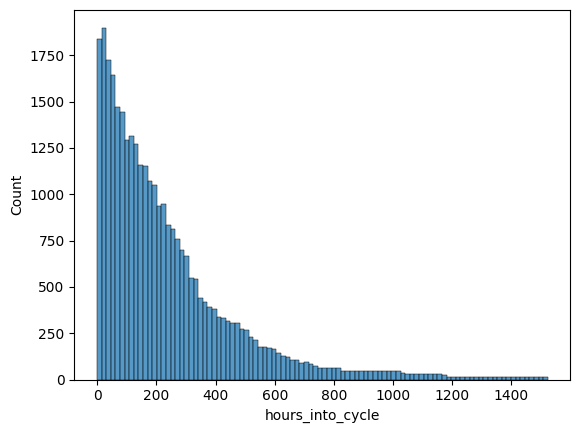

In [63]:
sns.histplot(data=df,x="hours_into_cycle")

    is_one_team             hours_bin  has_booking
0             0     (-2.474, 151.468]     0.014334
1             0    (151.468, 303.887]     0.012624
2             0    (303.887, 456.305]     0.013344
3             0    (456.305, 608.723]     0.023062
4             0    (608.723, 761.142]     0.008902
5             0     (761.142, 913.56]     0.018779
6             0    (913.56, 1065.978]     0.000000
7             0  (1065.978, 1218.397]     0.027273
8             1     (-2.474, 151.468]     0.012054
9             1    (151.468, 303.887]     0.005723
10            1    (303.887, 456.305]     0.006423
11            1    (456.305, 608.723]     0.006380
12            1    (608.723, 761.142]     0.000000
13            1     (761.142, 913.56]     0.000000
14            1    (913.56, 1065.978]     0.000000
15            1  (1065.978, 1218.397]     0.013072
16            1  (1218.397, 1370.815]     0.000000
17            1  (1370.815, 1523.233]     0.000000
    is_one_team             hou

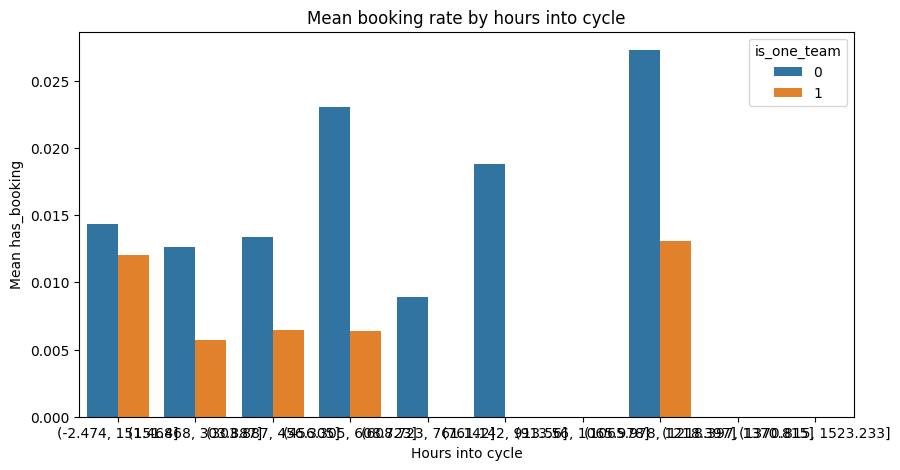

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

hour_bin = pd.cut(df["hours_into_cycle"],bins=10)
df = df.assign(hours_bin=hour_bin)
hours_into_share = df.groupby(['is_one_team',"hours_bin"])["has_booking"].mean().reset_index()
print(hours_into_share)

print(hours_into_share)
plt.figure(figsize=(10,5))
sns.barplot(data=hours_into_share,x="hours_bin", y="has_booking",hue="is_one_team")
plt.xlabel("Hours into cycle")
plt.ylabel("Mean has_booking")
plt.title("Mean booking rate by hours into cycle")
plt.show()

In [65]:
one_team_count = df["is_one_team"].value_counts(normalize=True)
print(one_team_count)



is_one_team
0    0.680783
1    0.319217
Name: proportion, dtype: float64


In [66]:
team_count= df.groupby(["is_one_team"])["has_booking"].mean()
print(team_count)


is_one_team
0    0.014195
1    0.007906
Name: has_booking, dtype: float64


In [67]:
class_count = df["class_type"].value_counts(normalize=True)
print(class_count)

class_type
1    0.637572
0    0.362428
Name: proportion, dtype: float64


In [68]:
class_count= df.groupby(["class_type"])["has_booking"].mean()
print(class_count)

class_type
0    0.009596
1    0.013661
Name: has_booking, dtype: float64


In [69]:
customer = df.drop_duplicates(["username"])[["is_one_team"]].value_counts()
print(customer)

is_one_team
0              26
1              11
Name: count, dtype: int64


In [70]:
heatmap = df.groupby(["polling_dow","polling_hour"])["has_booking"].mean().reset_index()

In [71]:
heatmap

,polling_dow,polling_hour,has_booking
0,0,0,0.000000
1,0,1,0.000000
2,0,2,0.000000
3,0,3,0.000000
4,0,4,0.000000
...,...,...,...
163,6,19,0.005348
164,6,20,0.000000
165,6,21,0.005348
166,6,22,0.010695


In [72]:
pv = pd.pivot(data=heatmap,index="polling_hour",columns="polling_dow",values="has_booking")

<Axes: xlabel='polling_dow', ylabel='polling_hour'>

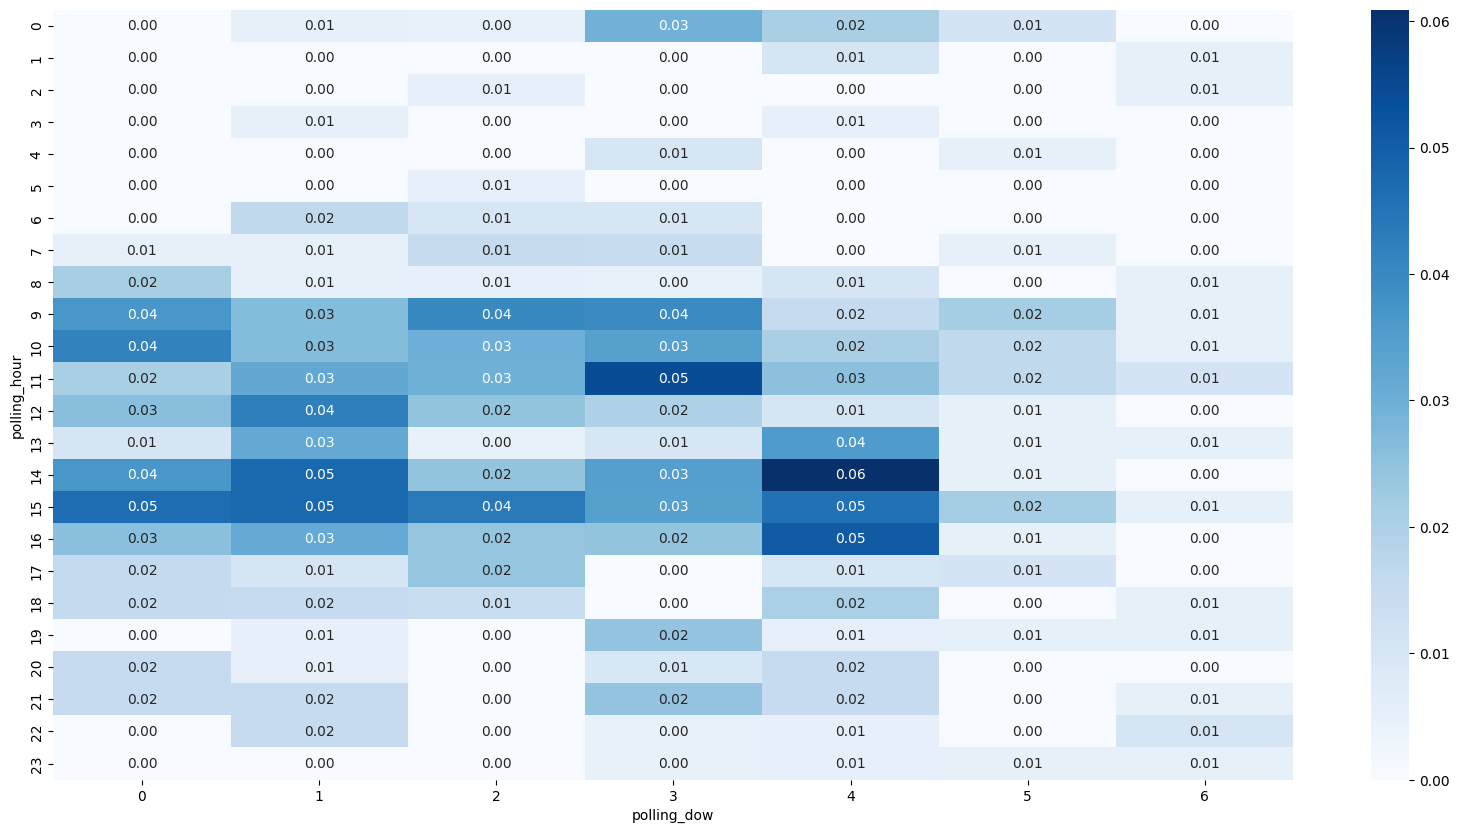

In [73]:
fig,ax = plt.subplots(figsize=(20,10))
sns.heatmap(pv,annot=True,fmt=".2f",cmap="Blues")

      username               cycle_start                 cycle_end  \
50      addity 2025-08-13 21:00:00+08:00 2025-08-28 11:36:00+08:00   
1783      matt 2025-08-12 01:21:00+08:00 2025-09-23 23:52:00+08:00   
9122       max 2025-09-24 00:00:00+08:00 2025-09-25 23:59:00+08:00   
13791    natar 2025-10-16 00:00:00+08:00 2025-10-17 23:59:00+08:00   
14376      mya 2025-10-29 16:15:00+08:00 2025-11-01 23:59:00+08:00   
17631     ryan 2025-11-01 21:30:00+08:00 2025-11-03 23:59:00+08:00   
22059   tomato 2025-11-26 11:00:00+08:00 2025-11-27 23:59:00+08:00   
25926     phuc 2025-12-30 16:00:00+08:00 2026-01-01 23:59:00+08:00   
26906  pakning 2026-01-20 17:00:00+08:00 2026-01-26 23:59:00+08:00   
30851      ali 2026-02-06 10:00:00+08:00 2026-02-25 23:59:00+08:00   
27455    faith 2026-02-27 00:00:00+08:00 2026-03-09 23:59:00+08:00   

       cycle_duration  
50         350.600000  
1783      1030.516667  
9122        47.983333  
13791       47.983333  
14376       79.733333  
17631       50.

<Axes: ylabel='cycle_duration'>

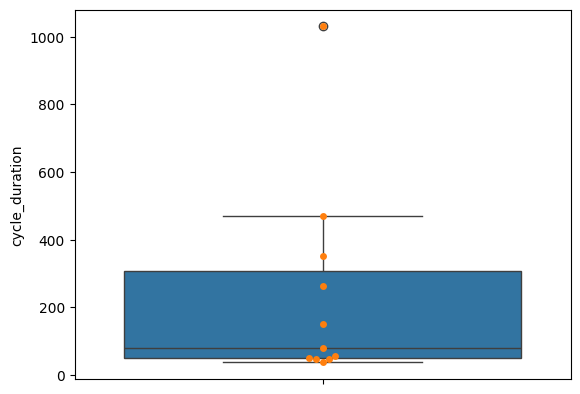

In [74]:
ot_customers = df.loc[df["is_one_team"]==1].sort_values("cycle_end").drop_duplicates(subset=["username"],keep="first")[["username","cycle_start","cycle_end"]]
ot_customers["cycle_duration"] = (ot_customers["cycle_end"] - ot_customers["cycle_start"]).dt.total_seconds()/3600
print(ot_customers)
sns.boxplot(data=ot_customers,y="cycle_duration")
sns.swarmplot(data=ot_customers,y="cycle_duration")

Overall base rate: 0.0122


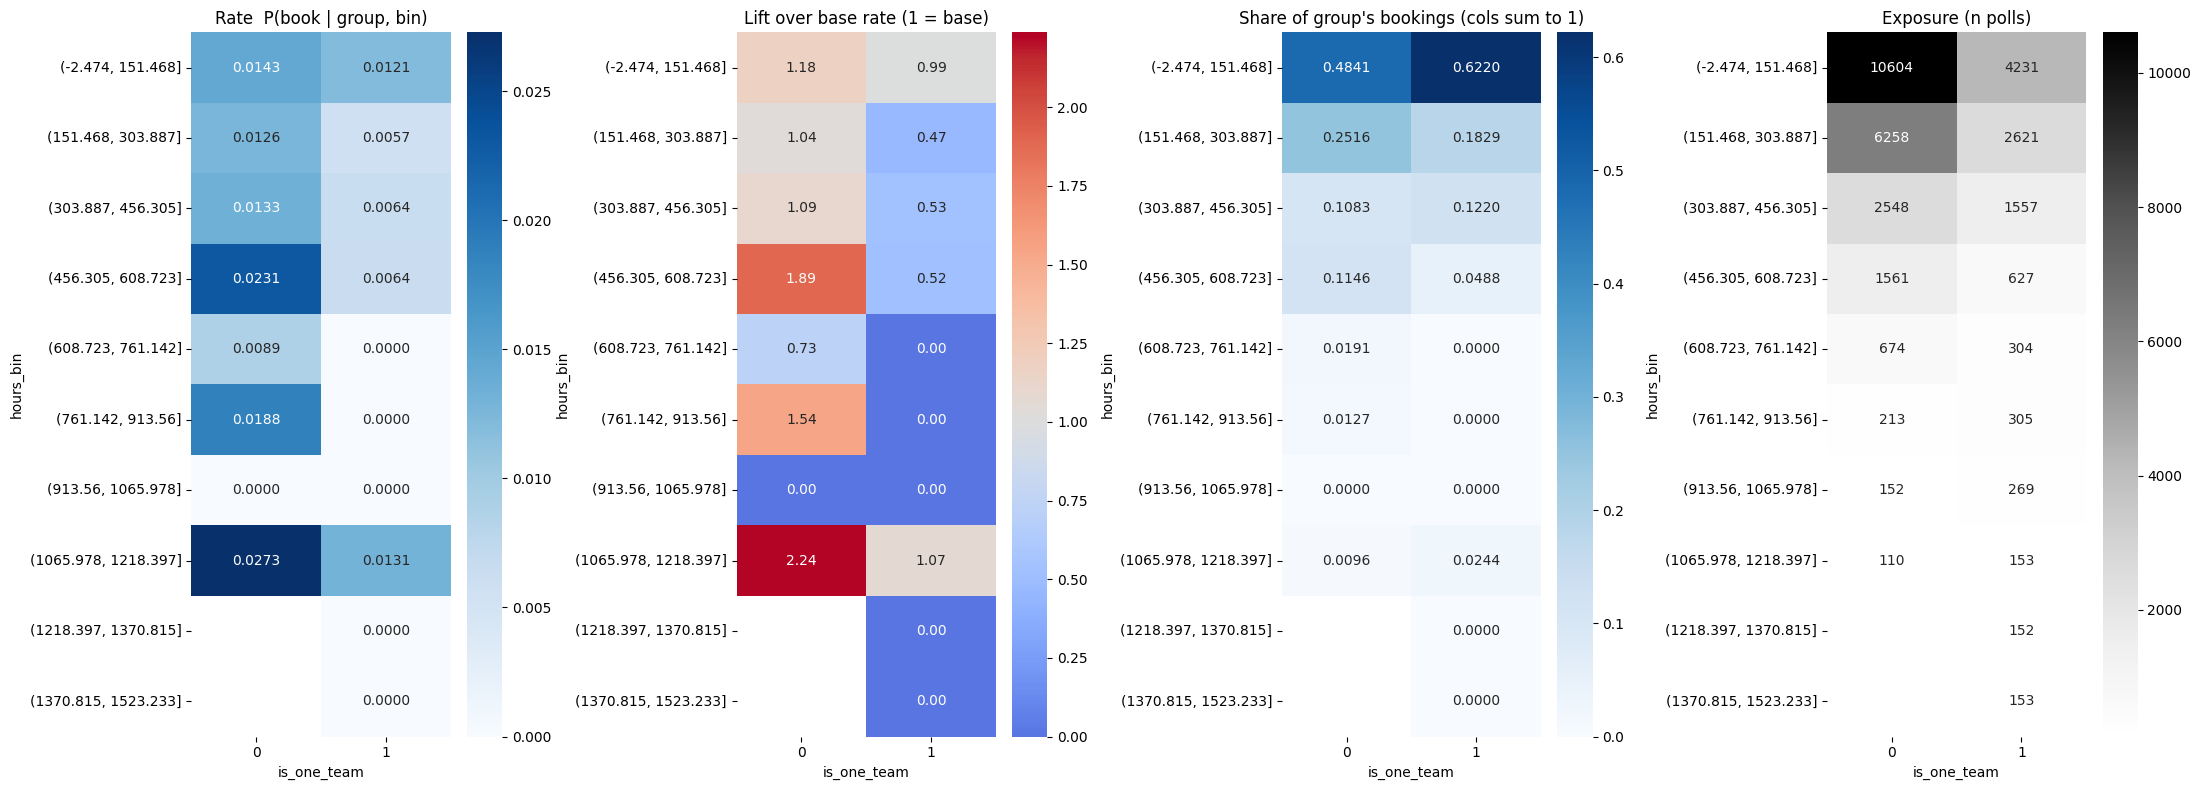

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

base_rate = df["has_booking"].mean()
print(f"Overall base rate: {base_rate:.4f}")

# one pass, all aggregates
g = (df.groupby(["is_one_team", "hours_bin"])["has_booking"]
       .agg(n_polls="count", n_bookings="sum", rate="mean")
       .reset_index())

# within-group totals for normalization
grp_bookings = df.groupby("is_one_team")["has_booking"].sum()

# share of THIS GROUP's bookings landing in this bin -> columns sum to ~1 -> tests concentration
g["share_of_group_bookings"] = g["n_bookings"] / g["is_one_team"].map(grp_bookings)
# multiplicative lift over base rate -> reads signal strength, not absolute smallness
g["lift"] = g["rate"] / base_rate

def pv(col):
    return pd.pivot(g, index="hours_bin", columns="is_one_team", values=col)

fig, axes = plt.subplots(1, 4, figsize=(22, 8))

sns.heatmap(pv("rate"), annot=True, fmt=".4f", cmap="Blues", ax=axes[0])
axes[0].set_title("Rate  P(book | group, bin)")

sns.heatmap(pv("lift"), annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[1])
axes[1].set_title("Lift over base rate (1 = base)")

sns.heatmap(pv("share_of_group_bookings"), annot=True, fmt=".4f", cmap="Blues", ax=axes[2])
axes[2].set_title("Share of group's bookings (cols sum to 1)")

sns.heatmap(pv("n_polls"), annot=True, fmt=".0f", cmap="Greys", ax=axes[3])
axes[3].set_title("Exposure (n polls)")

plt.tight_layout()
plt.show()

     polling_dow  polling_hour  has_booking
0              0             0     0.000000
1              0             1     0.000000
2              0             2     0.000000
3              0             3     0.000000
4              0             4     0.000000
..           ...           ...          ...
115            4            19     0.005102
116            4            20     0.015228
117            4            21     0.015464
118            4            22     0.005155
119            4            23     0.005155

[120 rows x 3 columns]
    polling_dow  polling_hour  has_booking
0             5             0     0.010811
1             5             1     0.000000
2             5             2     0.000000
3             5             3     0.000000
4             5             4     0.005405
5             5             5     0.000000
6             5             6     0.000000
7             5             7     0.005405
8             5             8     0.000000
9             5   

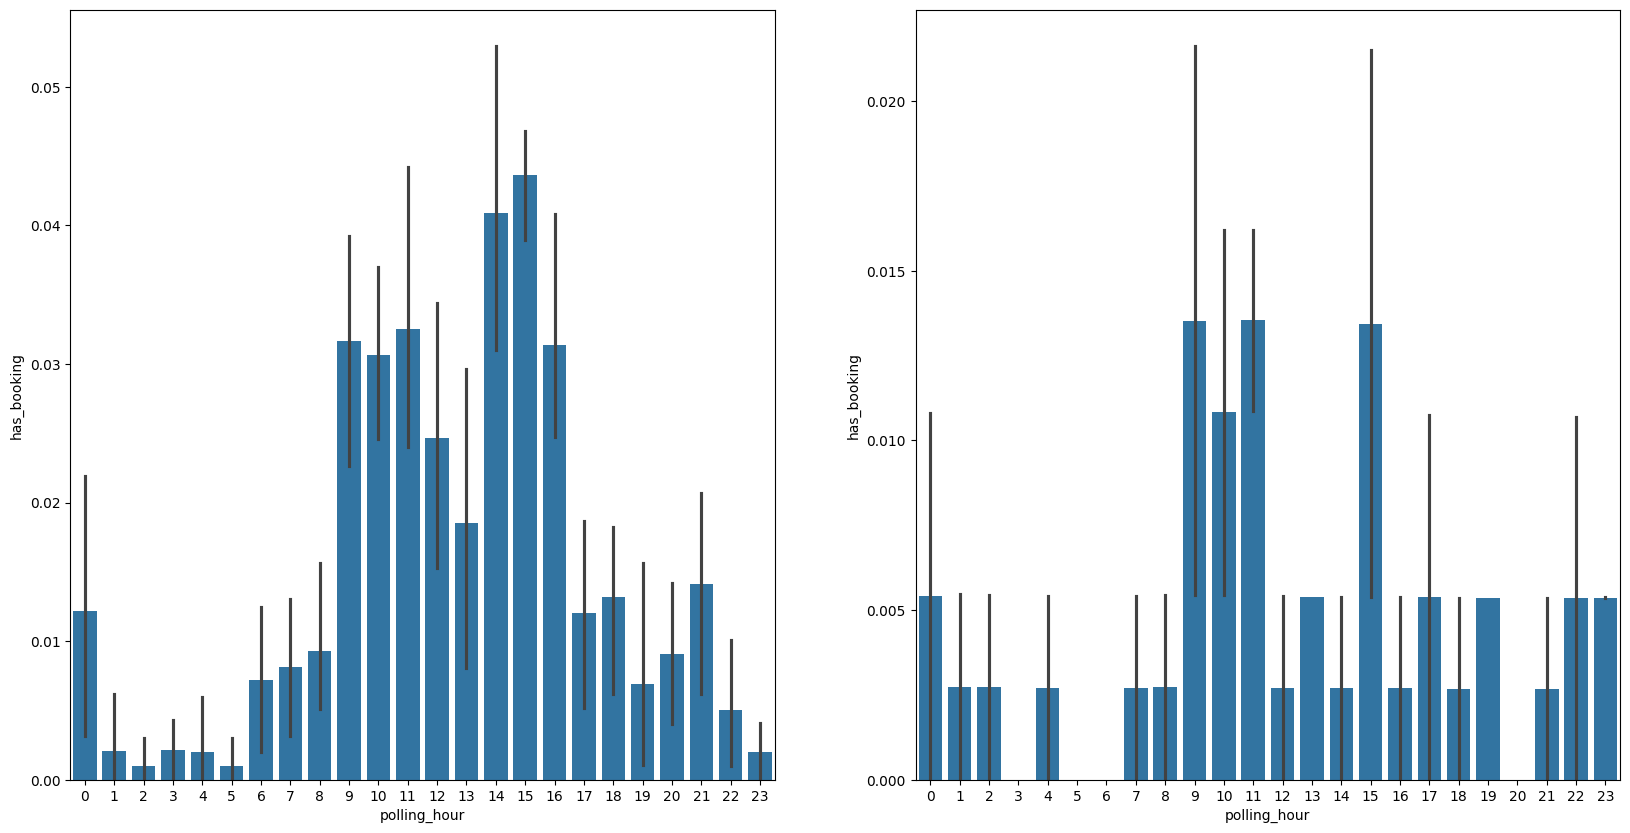

In [76]:
weekday_hour = df.loc[df["polling_dow"].isin([0,1,2,3,4])].groupby(["polling_dow","polling_hour"])["has_booking"].mean().reset_index()
print(weekday_hour)
fig,axes = plt.subplots(1,2,figsize=(20,10))
sns.barplot(data=weekday_hour,x="polling_hour",y="has_booking",ax=axes[0])
weekend_hour = df.loc[df["polling_dow"].isin([5,6])].groupby(["polling_dow","polling_hour"])["has_booking"].mean().reset_index()
sns.barplot(data=weekend_hour,x="polling_hour",y="has_booking",ax=axes[1])
print(weekend_hour)

                  sum  size      mean   logodds
wknd  block                                    
False night(0-5)   20  5833  0.003429 -5.672120
      morn(6-11)  117  5846  0.020014 -3.891122
      mid(12-17)  168  5918  0.028388 -3.532991
      eve(18-23)   50  5998  0.008336 -4.778787
True  night(0-5)    5  2212  0.002260 -6.089951
      morn(6-11)   16  2214  0.007227 -4.922714
      mid(12-17)   12  2231  0.005379 -5.219905
      eve(18-23)    8  2240  0.003571 -5.631212


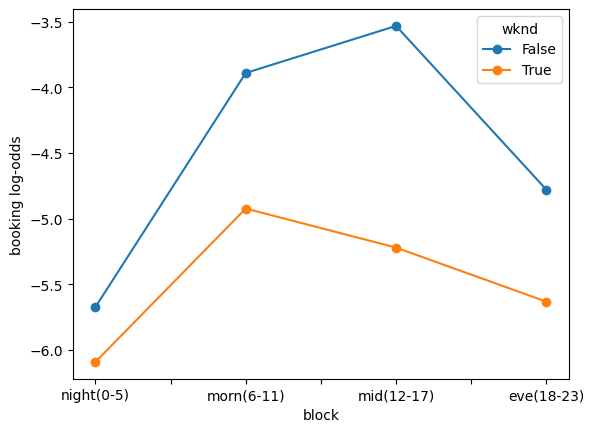

In [77]:
d = df.copy()
d["wknd"]  = d["polling_dow"].isin([5, 6])
d["block"] = pd.cut(d["polling_hour"], [-1, 5, 11, 17, 23],
                    labels=["night(0-5)", "morn(6-11)", "mid(12-17)", "eve(18-23)"])
g = d.groupby(["wknd", "block"], observed=True)["has_booking"].agg(["sum", "size", "mean"])
g["logodds"] = np.log(g["mean"].clip(1e-6, 1-1e-6) / (1 - g["mean"].clip(1e-6, 1-1e-6)))
print(g)                                    # check 'sum' (positives) is healthy per weekend block
g["logodds"].unstack(0).plot(marker="o")
plt.ylabel("booking log-odds"); plt.show()